In [1]:
import torch
import  torch.nn as nn
from torchvision.transforms import ToTensor
from torchvision.datasets import FashionMNIST

In [2]:
mnist_train_raw = FashionMNIST('.',download=True,train=True,transform=ToTensor())
mnist_test_raw = FashionMNIST('.',download=True,train=False,transform=ToTensor())

In [3]:
data_loader = torch.utils.data.DataLoader(mnist_train_raw, batch_size=64)    

In [27]:
data_loader_test = torch.utils.data.DataLoader(mnist_test_raw, batch_size=64)    

In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Avoid OpenMP crash



In [5]:
images, labels = next(iter(data_loader)) 

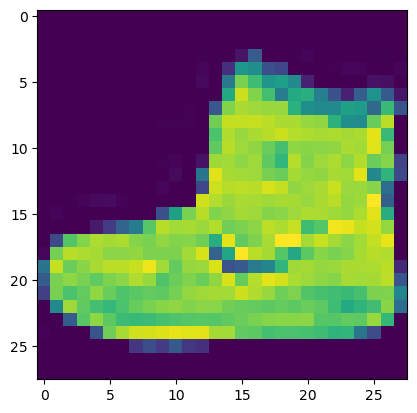

In [7]:
import matplotlib.pyplot as plt
plt.imshow(images[0,0])

In [15]:
class NNIC(nn.Module):
    def __init__(self,*args,**kwargs):
        super().__init__(*args,**kwargs)
        self.model = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        x = x.view(x.size(0), -1)
        pred = self.model(x)
        return pred



In [ ]:
def last_digit_counts(numbers):
    counts = {}
    for number in numbers:
        last_digit = number % 10
        counts[last_digit] = counts.get(last_digit, 0) + 1
    return counts


In [ ]:
def collinear(points):
    if len(points) < 3:
        return True  # Any two points are always collinear

    x0, y0 = points[0]
    x1, y1 = points[1]
    dx = x1 - x0
    dy = y1 - y0

    for x, y in points[2:]:
        if (x - x0) * dy != (y - y0) * dx:
            return False

    return True


In [38]:
import pyaudio

p = pyaudio.PyAudio()
for i in range(p.get_device_count()):
    info = p.get_device_info_by_index(i)
    print(f"{i}: {info['name']}")
p.terminate()

0: Microsoft Sound Mapper - Input
1: Microphone Array (Intel® Smart 
2: Stereo Mix (Realtek(R) Audio)
3: Microsoft Sound Mapper - Output
4: Speakers (Realtek(R) Audio)
5: Primary Sound Capture Driver
6: Microphone Array (Intel® Smart Sound Technology for Digital Microphones)
7: Stereo Mix (Realtek(R) Audio)
8: Primary Sound Driver
9: Speakers (Realtek(R) Audio)
10: Speakers (Realtek(R) Audio)
11: Microphone Array (Intel® Smart Sound Technology for Digital Microphones)
12: Stereo Mix (Realtek(R) Audio)
13: Microphone Array 1 ()
14: Microphone Array 2 ()
15: Microphone Array 3 ()
16: Headphones 1 (Realtek HD Audio 2nd output with SST)
17: Headphones 2 (Realtek HD Audio 2nd output with SST)
18: PC Speaker (Realtek HD Audio 2nd output with SST)
19: Stereo Mix (Realtek HD Audio Stereo input)
20: Speakers 1 (Realtek HD Audio output with SST)
21: Speakers 2 (Realtek HD Audio output with SST)
22: PC Speaker (Realtek HD Audio output with SST)
23: Microphone (Realtek HD Audio Mic input)


In [22]:
model = NNIC()
criternion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/experiment1")

In [37]:
from tqdm.notebook import tqdm
global_step = 0
model.train()
for epoch in tqdm(range(10)):
    for img, lbl in tqdm(data_loader):
        pred = model(img)

        loss = criternion(pred,lbl)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        writer.add_scalar("Loss/train", loss.item(), global_step)
        global_step+=1
    print(loss.item())
writer.close()



  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

0.37883397936820984


  0%|          | 0/938 [00:00<?, ?it/s]

0.28529685735702515


...

0.3152182698249817


  0%|          | 0/938 [00:00<?, ?it/s]

0.2631717324256897


  0%|          | 0/938 [00:00<?, ?it/s]

0.5155132412910461


In [29]:
model.eval()
with torch.no_grad():
    for x,y in data_loader_test:
        pred = model(x)

        loss = criternion(pred,y)
        print(loss.item())

0.3627791404724121
0.3153207004070282
0.35028624534606934
0.48150527477264404
0.2935449481010437
0.5993567705154419
0.3276640772819519
0.41017916798591614
0.4105510115623474
0.5234180688858032
0.5285651087760925
0.5397017002105713
0.44325461983680725
0.2994576096534729
0.24317669868469238
0.7086461186408997
0.20748364925384521
0.5617315173149109
0.4418160319328308
0.3097943663597107
0.8880897760391235
0.34191417694091797
0.489999383687973
0.4937790036201477
0.19515909254550934
0.5222499966621399
0.3148851692676544
0.5278728008270264
0.4069203734397888
0.17657797038555145
0.6311682462692261
0.947694718837738
0.4360407888889313
0.263130784034729
0.18525275588035583
0.39212626218795776
0.46176621317863464
0.6491517424583435
0.5318862199783325
0.649761438369751
0.6933996081352234
0.3659522533416748
0.48708823323249817
0.21297213435173035
0.6078667640686035
0.795070230960846
0.44230273365974426
0.8263241052627563
0.7368946075439453
0.3398330807685852
0.8223917484283447
0.787868857383728
0.3

In [30]:
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss
}
torch.save(checkpoint, "checkpoint.pth")

In [32]:
optimizer.state_dict()

{'state': {0: {'step': tensor(11984.),
   'exp_avg': tensor([[-5.6052e-45,  5.6052e-45,  5.6052e-45,  ..., -5.6052e-45,
            -5.6052e-45, -5.6052e-45],
           [-5.6052e-45, -5.6052e-45, -4.6483e-22,  ..., -1.0286e-21,
             5.6052e-45, -5.6052e-45],
           [-5.6052e-45,  5.6052e-45,  5.6052e-45,  ...,  5.6052e-45,
             5.6052e-45,  5.6052e-45],
           ...,
           [ 0.0000e+00,  0.0000e+00,  5.6052e-45,  ...,  5.6052e-45,
             0.0000e+00,  0.0000e+00],
           [ 5.6052e-45,  5.6052e-45,  5.6052e-45,  ...,  5.6052e-45,
             5.6052e-45,  5.6052e-45],
           [ 0.0000e+00,  0.0000e+00,  5.6052e-45,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]]),
   'exp_avg_sq': tensor([[3.2676e-17, 2.5632e-15, 5.5485e-13,  ..., 1.2535e-12, 6.0775e-13,
            5.3596e-14],
           [1.4007e-17, 6.7674e-14, 3.5751e-12,  ..., 2.4173e-12, 7.7322e-13,
            1.1976e-16],
           [2.1322e-17, 1.7692e-16, 3.4160e-15,  ..., 1.03

In [33]:
checkpoint = torch.load("checkpoint.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']


In [34]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/experiment1")